<div style="background:linear-gradient(135deg,#4F46E5 0%,#7E22CE 100%);
border-radius:14px;padding:30px 34px;color:#fff;font-family:'IBM Plex Sans','Segoe UI',system-ui,-apple-system,sans-serif;">
<div style="font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:13px;letter-spacing:.14em;opacity:.85;">INF672 · MACHINE LEARNING · NOTEBOOK · UATF</div>
<h1 style="margin:8px 0 6px 0;font-size:30px;font-weight:700;line-height:1.15;">Regresión Lineal Múltiple</h1>
<div style="font-size:17px;opacity:.95;">Dataset <i>Advertising</i> — predecir las ventas según la inversión publicitaria</div>
<div style="margin-top:16px;font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:12px;opacity:.8;">OLS · scikit-learn · TV · radio · newspaper</div>
</div>

Este notebook aplica **regresión lineal múltiple** para predecir las **ventas** (`sales`)
a partir de la inversión publicitaria en tres medios: **televisión** (`TV`),
**radio** (`radio`) y **prensa** (`newspaper`).

El dataset proviene de *An Introduction to Statistical Learning* (James, Witten,
Hastie & Tibshirani). Cada fila es un mercado; los presupuestos están en **miles de USD**
y las ventas en **miles de unidades**.

**Modelo:**

$$\text{sales} = \beta_0 + \beta_1 \cdot \text{TV} + \beta_2 \cdot \text{radio} + \beta_3 \cdot \text{newspaper} + \varepsilon$$

El objetivo es estimar los coeficientes $\beta_j$ que minimizan el error cuadrático
(mínimos cuadrados ordinarios, OLS), interpretarlos y evaluar la capacidad predictiva
del modelo sobre datos no vistos.

<div style="border-left:4px solid #6B7280;background:rgba(107,114,128,0.08);padding:12px 16px;margin:6px 0;border-radius:0 8px 8px 0;font-family:'IBM Plex Sans','Segoe UI',system-ui,-apple-system,sans-serif;color:#111827;"><div style="font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#6B7280;font-weight:600;margin-bottom:4px;">Requisito</div><div style="font-size:15px;line-height:1.6;">El archivo <code>Advertising.csv</code> debe estar en la misma carpeta que este notebook.</div></div>

## 1. Importación de librerías

Usamos `pandas` para manejar los datos, `matplotlib` para las gráficas y el ecosistema
`scikit-learn` para el modelo y su evaluación.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Semilla global para reproducibilidad
RANDOM_STATE = 42

# --- Identidad visual INF672 "cuaderno cientifico" ---
C_DATOS  = "#4F46E5"   # indigo  -> datos
C_MODELO = "#7E22CE"   # purpura -> modelo / referencia
C_ACENTO = "#F43F5E"   # coral   -> acentos / diagnostico
INK      = "#111827"
# Mapa de color divergente de la materia (indigo -> blanco -> coral)
CMAP_MATERIA = LinearSegmentedColormap.from_list("inf672", ["#4F46E5", "#FFFFFF", "#F43F5E"])

plt.rcParams.update({
    "axes.prop_cycle": cycler(color=[C_DATOS, C_MODELO, C_ACENTO, "#0891B2", "#16A34A"]),
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.7,
    "axes.edgecolor": "#D1D5DB",
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.labelcolor": INK,
})
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 2. Carga y primera inspección de los datos

Cargamos el CSV. El archivo incluye una primera columna de índice (`Unnamed: 0`)
que **no es una variable**, así que la descartamos. Siempre conviene revisar la forma
del dataset, los tipos de dato y la presencia de valores nulos antes de modelar.

In [2]:
df = pd.read_csv("Advertising.csv")

# Descartamos la columna índice si está presente
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (200, 4)


,TV,radio,newspaper,sales
0,230.1000,37.8000,69.2000,22.1000
1,44.5000,39.3000,45.1000,10.4000
2,17.2000,45.9000,69.3000,9.3000
3,151.5000,41.3000,58.5000,18.5000
4,180.8000,10.8000,58.4000,12.9000


In [3]:
# Tipos de dato y valores nulos
print("Tipos de dato:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Tipos de dato:
TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

Valores nulos por columna:
TV           0
radio        0
newspaper    0
sales        0
dtype: int64


## 3. Análisis exploratorio (EDA)

Antes de ajustar el modelo observamos dos cosas: la **distribución** de cada variable
(estadísticos descriptivos) y las **relaciones** entre ellas (correlaciones).

In [4]:
df.describe()

,TV,radio,newspaper,sales
count,200.0000,200.0000,200.0000,200.0000
mean,147.0425,23.2640,30.5540,14.0225
std,85.8542,14.8468,21.7786,5.2175
min,0.7000,0.0000,0.3000,1.6000
25%,74.3750,9.9750,12.7500,10.3750
50%,149.7500,22.9000,25.7500,12.9000
75%,218.8250,36.5250,45.1000,17.4000
max,296.4000,49.6000,114.0000,27.0000


### 3.1 Matriz de correlación

La correlación de Pearson mide la relación lineal entre pares de variables (rango −1 a 1).
Nos interesan dos lecturas:

- Cuánto se relaciona **cada predictor con `sales`** (última columna).
- Cuánto se relacionan **los predictores entre sí** (posible colinealidad).

In [5]:
corr = df.corr()
corr

,TV,radio,newspaper,sales
TV,1.0000,0.0548,0.0566,0.7822
radio,0.0548,1.0000,0.3541,0.5762
newspaper,0.0566,0.3541,1.0000,0.2283
sales,0.7822,0.5762,0.2283,1.0000


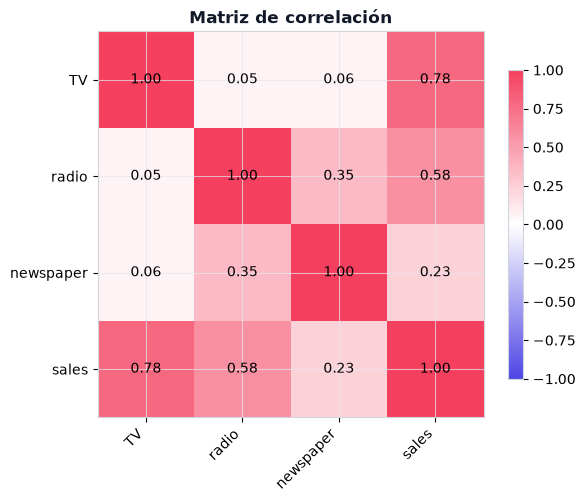

In [6]:
# Visualización de la matriz de correlación
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap=CMAP_MATERIA, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

<div style="border-left:4px solid #4F46E5;background:rgba(79,70,229,0.07);padding:12px 16px;margin:6px 0;border-radius:0 8px 8px 0;font-family:'IBM Plex Sans','Segoe UI',system-ui,-apple-system,sans-serif;color:#111827;"><div style="font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#4F46E5;font-weight:600;margin-bottom:4px;">Observación clave</div><div style="font-size:15px;line-height:1.6;"><code>TV</code> (0.78) y <code>radio</code> (0.58) están fuertemente asociadas con las ventas;
<code>newspaper</code> apenas (0.23). Además, <code>newspaper</code> y <code>radio</code> están
correlacionadas entre sí (0.35). Retén este dato: explicará por qué el coeficiente de
<code>newspaper</code> se comportará de forma «sorprendente» en el modelo múltiple.</div></div>

### 3.2 Relación de cada predictor con las ventas

Un gráfico de dispersión por medio permite ver la forma de cada relación.

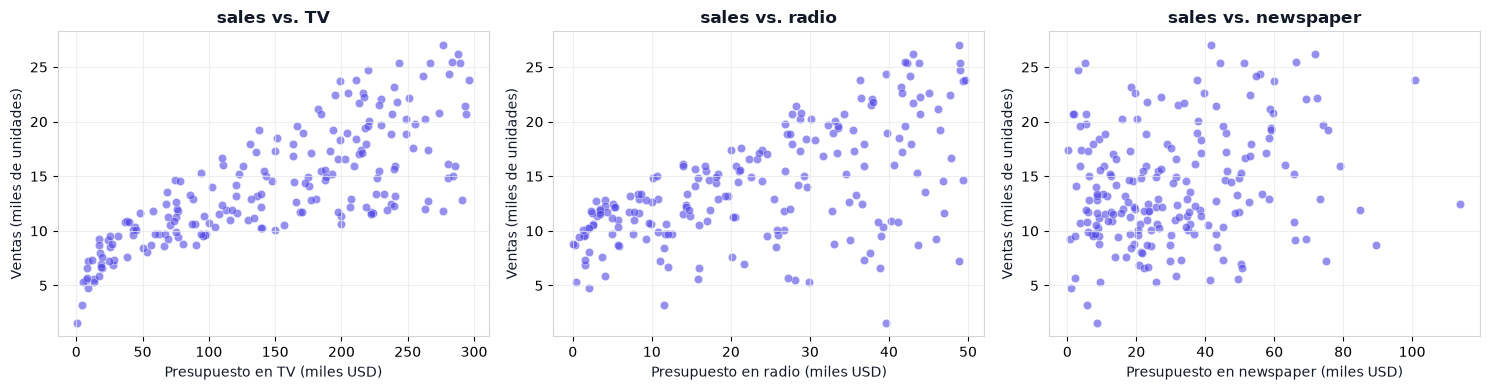

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TV", "radio", "newspaper"]):
    ax.scatter(df[col], df["sales"], color=C_DATOS, alpha=0.6, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(f"Presupuesto en {col} (miles USD)")
    ax.set_ylabel("Ventas (miles de unidades)")
    ax.set_title(f"sales vs. {col}")
plt.tight_layout()
plt.show()

## 4. Preparación de los datos

Separamos la **matriz de características** `X` (los tres predictores) del **vector objetivo**
`y` (las ventas). scikit-learn espera `X` en forma bidimensional (`n_muestras × n_features`)
e `y` en forma unidimensional.

In [8]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

print("X:", X.shape, " y:", y.shape)

X: (200, 3)  y: (200,)


### 4.1 Partición entrenamiento / prueba

Reservamos un **20 %** de los datos como conjunto de prueba. El modelo se ajusta solo
con el 80 % de entrenamiento y se evalúa sobre datos que **no vio**, para estimar cómo
generalizaría a mercados nuevos. `random_state` fija la partición para que el experimento
sea reproducible.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Entrenamiento:", X_train.shape[0], "muestras")
print("Prueba       :", X_test.shape[0], "muestras")

Entrenamiento: 160 muestras
Prueba       : 40 muestras


## 5. Entrenamiento del modelo

`LinearRegression` de scikit-learn resuelve los mínimos cuadrados ordinarios por álgebra
lineal (no requiere hiperparámetros). El método `fit` estima los coeficientes con los
datos de entrenamiento.

In [10]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado.")
print("Intercepto (β0):", round(modelo.intercept_, 4))

Modelo entrenado.
Intercepto (β0): 2.9791


### 5.1 Coeficientes estimados e interpretación

Cada coeficiente indica cuánto cambia la venta estimada (en miles de unidades) por cada
**unidad adicional de presupuesto (mil USD)** en ese medio, **manteniendo los demás
constantes**.

In [11]:
coeficientes = pd.DataFrame({
    "Predictor": X.columns,
    "Coeficiente": modelo.coef_
})
coeficientes

,Predictor,Coeficiente
0,TV,0.0447
1,radio,0.1892
2,newspaper,0.0028


In [12]:
# Ecuación del modelo ajustado
terminos = " + ".join(f"{c:.4f}·{n}" for n, c in zip(X.columns, modelo.coef_))
print(f"sales = {modelo.intercept_:.4f} + {terminos}")

sales = 2.9791 + 0.0447·TV + 0.1892·radio + 0.0028·newspaper


<div style="border-left:4px solid #16A34A;background:rgba(22,163,74,0.07);padding:12px 16px;margin:6px 0;border-radius:0 8px 8px 0;font-family:'IBM Plex Sans','Segoe UI',system-ui,-apple-system,sans-serif;color:#111827;"><div style="font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#16A34A;font-weight:600;margin-bottom:4px;">Interpretación de los coeficientes</div><div style="font-size:15px;line-height:1.6;"><ul style="margin:6px 0 0 0;padding-left:20px;">
<li><b>TV</b> (~0.045): cada mil USD extra en televisión suma ~45 unidades vendidas.</li>
<li><b>radio</b> (~0.19): es el de <b>mayor impacto marginal</b> — ~190 unidades por mil USD.</li>
<li><b>newspaper</b> (~0.00): su coeficiente es prácticamente nulo. Aunque su correlación
<i>marginal</i> con las ventas era positiva (0.23), al controlar por radio su aporte desaparece:
la prensa «parecía» vender solo por ir acompañada de la radio. Es el ejemplo clásico de que
<b>correlación marginal &ne; efecto en un modelo multivariado</b>.</li></ul></div></div>

## 6. Predicción y evaluación

Predecimos sobre el conjunto de prueba y medimos el error con cuatro métricas:

| Métrica | Qué mide | Ideal |
|---|---|---|
| **R²** | Proporción de varianza explicada | cercano a 1 |
| **MSE** | Error cuadrático medio | bajo |
| **RMSE** | Raíz del MSE, en las unidades de `sales` | bajo |
| **MAE** | Error absoluto medio | bajo |

In [13]:
y_pred = modelo.predict(X_test)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  (error típico en miles de unidades)")
print(f"MAE  : {mae:.4f}")

R²   : 0.8994
MSE  : 3.1741
RMSE : 1.7816  (error típico en miles de unidades)
MAE  : 1.4608


<div style="border-left:4px solid #6B7280;background:rgba(107,114,128,0.08);padding:12px 16px;margin:6px 0;border-radius:0 8px 8px 0;font-family:'IBM Plex Sans','Segoe UI',system-ui,-apple-system,sans-serif;color:#111827;"><div style="font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#6B7280;font-weight:600;margin-bottom:4px;">Resultado</div><div style="font-size:15px;line-height:1.6;">El modelo explica cerca del <b>90 %</b> de la variabilidad de las ventas en datos no vistos,
con un error típico (RMSE) de aproximadamente 1.8 mil unidades.</div></div>

### 6.1 Ventas reales vs. predichas

Si el modelo fuera perfecto, todos los puntos caerían sobre la diagonal roja.

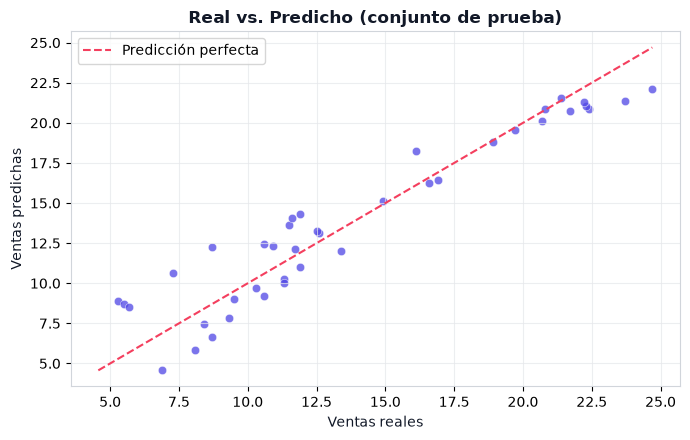

In [14]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, color=C_DATOS, alpha=0.75, edgecolor="white", linewidth=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "--", color=C_ACENTO, label="Predicción perfecta")
ax.set_xlabel("Ventas reales")
ax.set_ylabel("Ventas predichas")
ax.set_title("Real vs. Predicho (conjunto de prueba)")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Análisis de residuos

Los **residuos** (real − predicho) deberían distribuirse aleatoriamente alrededor de cero,
sin patrón. Un patrón sistemático indica que el modelo lineal se está dejando estructura
sin capturar.

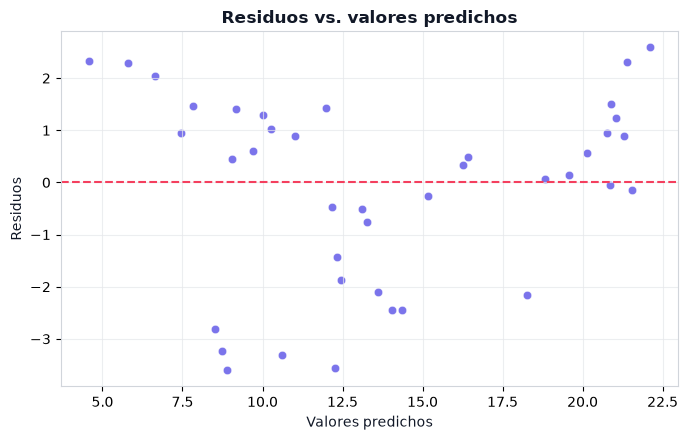

In [15]:
residuos = y_test - y_pred

fig, ax = plt.subplots()
ax.scatter(y_pred, residuos, color=C_DATOS, alpha=0.75, edgecolor="white", linewidth=0.4)
ax.axhline(0, color=C_ACENTO, linestyle="--")
ax.set_xlabel("Valores predichos")
ax.set_ylabel("Residuos")
ax.set_title("Residuos vs. valores predichos")
plt.tight_layout()
plt.show()

<div style="border-left:4px solid #F43F5E;background:rgba(244,63,94,0.07);padding:12px 16px;margin:6px 0;border-radius:0 8px 8px 0;font-family:'IBM Plex Sans','Segoe UI',system-ui,-apple-system,sans-serif;color:#111827;"><div style="font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#F43F5E;font-weight:600;margin-bottom:4px;">Diagnóstico de residuos</div><div style="font-size:15px;line-height:1.6;">En este dataset se aprecia una leve <b>curvatura en U</b> en los residuos: el modelo puramente
lineal subestima en los extremos. Ello sugiere un efecto <b>no lineal</b> — en particular, una
<b>sinergia TV&times;radio</b> (la radio potencia el rendimiento de la TV) que un término de
interacción capturaría. Es una buena transición hacia modelos con interacciones o regresión
polinómica.</div></div>

## 7. Modelo reducido: ¿aporta algo `newspaper`?

Dado que su coeficiente fue casi nulo, comparamos el modelo completo contra uno que usa
**solo TV y radio**. Si el desempeño no baja, el modelo más simple (parsimonioso) es preferible.

In [16]:
X_red = df[["TV", "radio"]]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y, test_size=0.2, random_state=RANDOM_STATE
)

modelo_red = LinearRegression().fit(Xr_train, yr_train)
yr_pred = modelo_red.predict(Xr_test)

print("=== Comparación en el conjunto de prueba ===")
print(f"Completo (TV+radio+newspaper) -> R²: {r2:.4f} | RMSE: {rmse:.4f}")
print(f"Reducido (TV+radio)           -> R²: {r2_score(yr_test, yr_pred):.4f} "
      f"| RMSE: {np.sqrt(mean_squared_error(yr_test, yr_pred)):.4f}")

=== Comparación en el conjunto de prueba ===
Completo (TV+radio+newspaper) -> R²: 0.8994 | RMSE: 1.7816
Reducido (TV+radio)           -> R²: 0.9006 | RMSE: 1.7714


<div style="border-left:4px solid #16A34A;background:rgba(22,163,74,0.07);padding:12px 16px;margin:6px 0;border-radius:0 8px 8px 0;font-family:'IBM Plex Sans','Segoe UI',system-ui,-apple-system,sans-serif;color:#111827;"><div style="font-family:'IBM Plex Mono','Consolas','Courier New',monospace;font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#16A34A;font-weight:600;margin-bottom:4px;">Conclusión práctica</div><div style="font-size:15px;line-height:1.6;">El modelo reducido rinde <b>igual o mejor</b> que el completo: <code>newspaper</code> no aporta
poder predictivo y puede eliminarse en favor de un modelo más simple (parsimonioso).</div></div>

## 8. Predicción sobre un caso nuevo

Ejemplo de uso del modelo ya entrenado para estimar las ventas de un mercado hipotético.

In [17]:
nuevo = pd.DataFrame([{"TV": 150.0, "radio": 25.0, "newspaper": 20.0}])
estimacion = modelo.predict(nuevo)[0]
print(f"Presupuesto -> TV=150, radio=25, newspaper=20 (miles USD)")
print(f"Ventas estimadas: {estimacion:.2f} mil unidades")

Presupuesto -> TV=150, radio=25, newspaper=20 (miles USD)
Ventas estimadas: 14.47 mil unidades


## 9. Conclusiones

1. La regresión lineal múltiple explica **~90 %** de la variabilidad de las ventas (R² ≈ 0.90
   en prueba y en validación cruzada).
2. **TV y radio** son predictores fuertes y significativos; **radio** tiene el mayor efecto
   marginal por unidad de presupuesto.
3. **newspaper no aporta**: su efecto marginal aparente se debe a su correlación con radio.
   El modelo reducido (TV + radio) es igual de bueno y más simple.
4. Los residuos muestran una **leve no linealidad** compatible con una **sinergia TV×radio**,
   que motiva extender el modelo con un término de interacción.

**Extensiones sugeridas:** añadir el término `TV·radio`, aplicar regularización
(Ridge/Lasso) y estandarizar las variables para comparar magnitudes de coeficientes.